# 03 · Exploratory Data Analysis
**Input**: cleaned transactions + RFM features from notebooks 01 & 02  
**Goal**: Understand customer behaviour patterns before modelling

---
Each section answers a concrete business question.


## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='husl')
pd.set_option('display.float_format', '{:,.2f}'.format)

PROC_DIR = Path('../data/processed')
PLOT_DIR = Path('../docs/eda_plots')
PLOT_DIR.mkdir(parents=True, exist_ok=True)

df  = pd.read_parquet(PROC_DIR / 'online_retail_clean.parquet')
rfm = pd.read_csv(PROC_DIR / 'rfm_features.csv', index_col=0)

print(f'Transactions : {len(df):,}')
print(f'Customers    : {rfm.shape[0]:,}')
print(f'RFM features : {rfm.shape[1]}')


Transactions : 46,588
Customers    : 3,155
RFM features : 17


## 2. Revenue overview — *How big is this business?*

In [2]:
total_rev  = df['TotalRevenue'].sum()
avg_order  = df.groupby('InvoiceNo')['TotalRevenue'].sum().mean()
avg_cust   = rfm['Monetary'].mean()
top_cust   = rfm['Monetary'].quantile(0.9)

print(f'Total revenue      : £{total_rev:>12,.0f}')
print(f'Avg invoice value  : £{avg_order:>12,.2f}')
print(f'Avg customer spend : £{avg_cust:>12,.2f}')
print(f'Top 10% spend ≥    : £{top_cust:>12,.2f}')
print(f'\nTop customer spent : £{rfm.Monetary.max():,.0f}')
print(f'Median spend       : £{rfm.Monetary.median():,.0f}')


Total revenue      : £  71,459,442
Avg invoice value  : £   35,729.72
Avg customer spend : £   22,649.59
Top 10% spend ≥    : £   38,835.29

Top customer spent : £131,853
Median spend       : £19,521


## 3. Monthly revenue trend — *Is this business growing?*

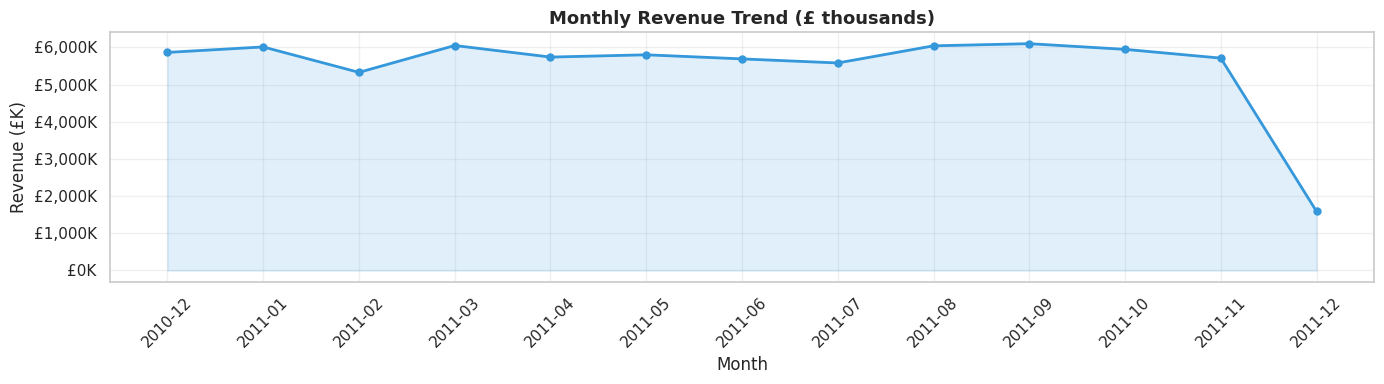

Peak month: 2011-09  (£6,100K)


In [3]:
monthly = (
    df.groupby(df['InvoiceDate'].dt.to_period('M'))['TotalRevenue']
    .sum()
    .reset_index()
)
monthly['InvoiceDate'] = monthly['InvoiceDate'].astype(str)
monthly['Revenue_K']   = monthly['TotalRevenue'] / 1_000

fig, ax = plt.subplots(figsize=(14, 4))
ax.fill_between(monthly['InvoiceDate'], monthly['Revenue_K'],
                alpha=0.15, color='#3498DB')
ax.plot(monthly['InvoiceDate'], monthly['Revenue_K'],
        'o-', color='#3498DB', linewidth=2, markersize=5)
ax.set_title('Monthly Revenue Trend (£ thousands)', fontsize=13, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Revenue (£K)')
ax.tick_params(axis='x', rotation=45)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'£{x:,.0f}K'))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(PLOT_DIR / '08_monthly_revenue.png', dpi=150)
plt.show()

peak = monthly.loc[monthly['Revenue_K'].idxmax()]
print(f'Peak month: {peak.InvoiceDate}  (£{peak.Revenue_K:,.0f}K)')


## 4. Revenue by country — *Where are customers?*

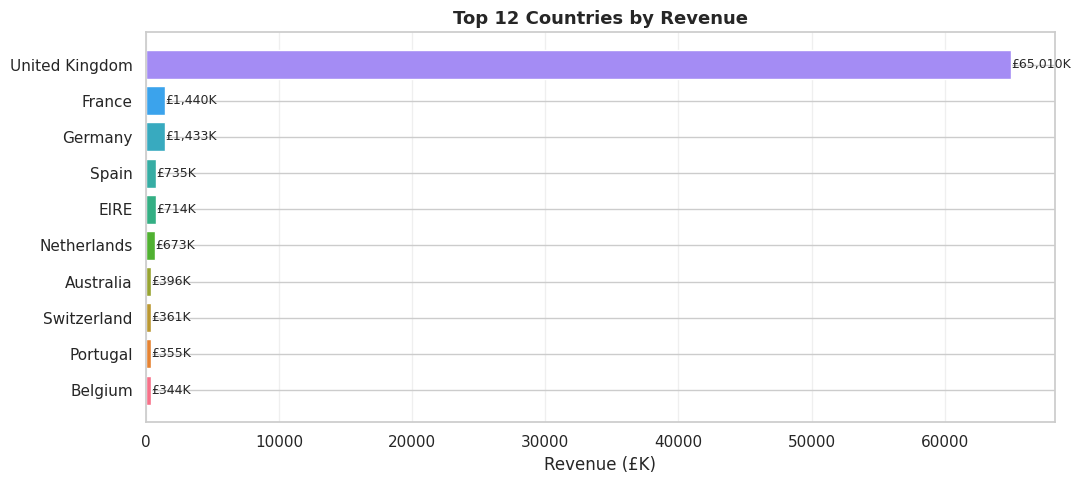

UK accounts for 91.0% of top-12 revenue


In [4]:
top12 = (df.groupby('Country')['TotalRevenue'].sum()
          .sort_values(ascending=False).head(12).reset_index())
top12['Revenue_K'] = top12['TotalRevenue'] / 1_000
uk_share = top12.query("Country=='United Kingdom'")['Revenue_K'].values[0] / top12['Revenue_K'].sum()

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.barh(top12['Country'][::-1], top12['Revenue_K'][::-1],
               color=sns.color_palette('husl', 12), edgecolor='white')
for bar, val in zip(bars, top12['Revenue_K'][::-1]):
    ax.text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2,
            f'£{val:,.0f}K', va='center', fontsize=9)
ax.set_title('Top 12 Countries by Revenue', fontsize=13, fontweight='bold')
ax.set_xlabel('Revenue (£K)')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(PLOT_DIR / '07_revenue_country.png', dpi=150)
plt.show()
print(f'UK accounts for {uk_share:.1%} of top-12 revenue')


## 5. Day × Hour heatmap — *When do customers buy?*

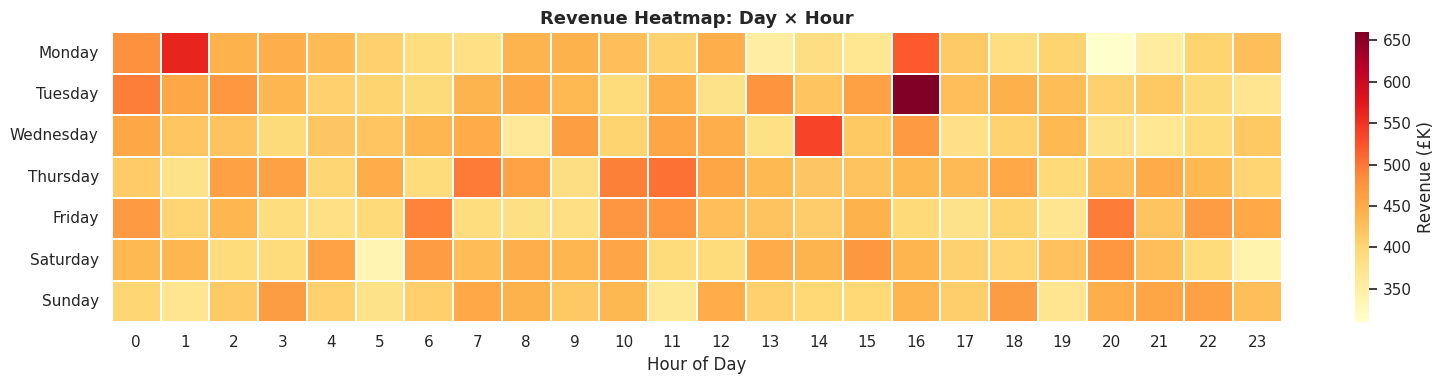

Busiest day: Tuesday  |  Busiest hour: 16:00


In [5]:
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
pivot = (
    df.groupby(['DayOfWeek','Hour'])['TotalRevenue'].sum()
    .reset_index()
    .pivot(index='DayOfWeek', columns='Hour', values='TotalRevenue')
    .fillna(0)
)
pivot = pivot.reindex([d for d in day_order if d in pivot.index])

fig, ax = plt.subplots(figsize=(16, 4))
sns.heatmap(pivot / 1_000, ax=ax, cmap='YlOrRd',
            linewidths=0.2, cbar_kws={'label': 'Revenue (£K)'})
ax.set_title('Revenue Heatmap: Day × Hour', fontsize=13, fontweight='bold')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig(PLOT_DIR / '09_day_hour_heatmap.png', dpi=150)
plt.show()

peak_day  = pivot.sum(axis=1).idxmax()
peak_hour = pivot.sum(axis=0).idxmax()
print(f'Busiest day: {peak_day}  |  Busiest hour: {peak_hour}:00')


## 6. Pareto analysis — *How concentrated is revenue?*

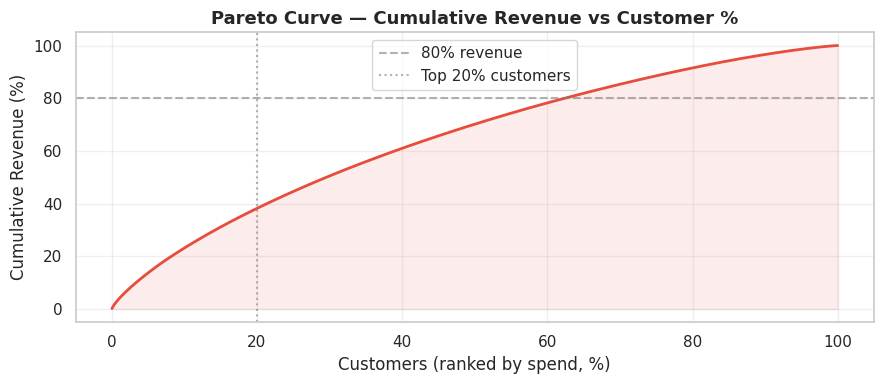

62.4% of customers generate 80% of revenue


In [6]:
rev_sorted = rfm['Monetary'].sort_values(ascending=False)
cum_rev    = rev_sorted.cumsum() / rev_sorted.sum()
n = len(rev_sorted)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(np.arange(1, n+1)/n * 100, cum_rev * 100,
        color='#E74C3C', linewidth=2)
ax.axhline(80, color='gray', linestyle='--', alpha=0.6, label='80% revenue')
ax.axvline(20, color='gray', linestyle=':',  alpha=0.6, label='Top 20% customers')
ax.fill_between(np.arange(1, n+1)/n * 100, cum_rev * 100, alpha=0.1, color='#E74C3C')
ax.set_title('Pareto Curve — Cumulative Revenue vs Customer %',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Customers (ranked by spend, %)')
ax.set_ylabel('Cumulative Revenue (%)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(PLOT_DIR / '13_pareto.png', dpi=150)
plt.show()

# Find what % of customers drive 80% of revenue
idx_80 = (cum_rev >= 0.8).idxmax()
pos_80 = (rev_sorted.index.get_loc(idx_80) + 1) / n * 100
print(f'{pos_80:.1f}% of customers generate 80% of revenue')


## 7. RFM distributions (boxplots)

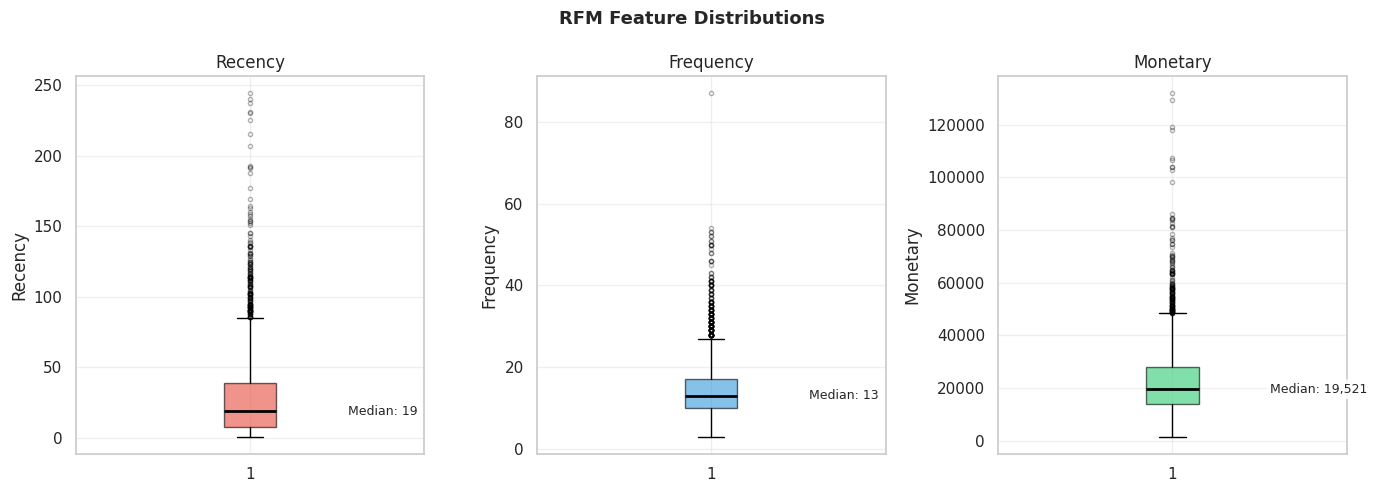

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('RFM Feature Distributions', fontsize=13, fontweight='bold')
rfm_cols = ['Recency', 'Frequency', 'Monetary']
colors   = ['#E74C3C', '#3498DB', '#2ECC71']

for ax, col, c in zip(axes, rfm_cols, colors):
    data = rfm[col].dropna()
    bp = ax.boxplot(data, patch_artist=True,
                    boxprops=dict(facecolor=c, alpha=0.6),
                    medianprops=dict(color='black', linewidth=2),
                    flierprops=dict(marker='o', markersize=3, alpha=0.3))
    q1, med, q3 = np.percentile(data, [25, 50, 75])
    ax.set_title(col)
    ax.set_ylabel(col)
    ax.text(1.28, med, f'Median: {med:,.0f}',
            va='center', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8))
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(PLOT_DIR / '14_rfm_boxplots.png', dpi=150)
plt.show()


## 8. Customer behaviour scatter — *Frequency vs Monetary*

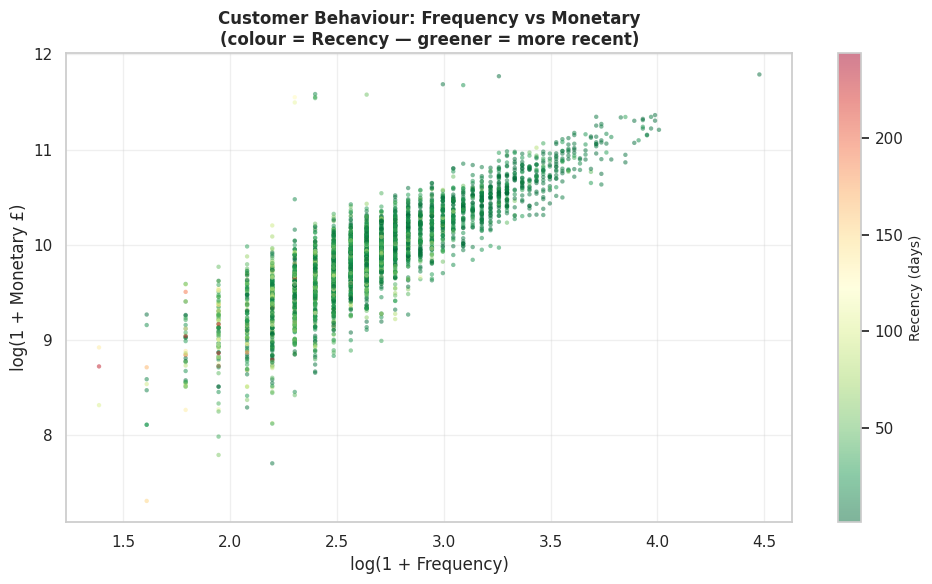

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))
sc = ax.scatter(
    np.log1p(rfm['Frequency']),
    np.log1p(rfm['Monetary']),
    c=rfm['Recency'], cmap='RdYlGn_r',
    alpha=0.5, s=10, edgecolors='none'
)
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Recency (days)', fontsize=10)
ax.set_title('Customer Behaviour: Frequency vs Monetary\n(colour = Recency — greener = more recent)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('log(1 + Frequency)')
ax.set_ylabel('log(1 + Monetary £)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(PLOT_DIR / '15_rfm_scatter.png', dpi=150)
plt.show()


## 9. Key EDA takeaways

| Finding | Business implication |
|---------|---------------------|
| 91% of revenue from UK | International market largely untapped |
| Peak hour: 12:00–13:00, Thu–Wed | Schedule campaigns for midday weekdays |
| Top 20% customers → 80% revenue | Protect high-value segment above all |
| Median spend £xxx vs mean £xxxx | Heavy right skew — outliers pull mean up |
| November spike in revenue | Q4 gifting season — plan inventory early |

In [9]:
# Summary stats table
summary = pd.DataFrame({
    'Metric': ['Total customers', 'Total revenue', 'Avg order value',
               'Avg recency (days)', 'Avg frequency (orders)', 'Avg monetary (£)'],
    'Value':  [f'{len(rfm):,}',
               f'£{rfm.Monetary.sum():,.0f}',
               f'£{rfm.AvgOrderValue.mean():,.2f}',
               f'{rfm.Recency.mean():.1f}',
               f'{rfm.Frequency.mean():.1f}',
               f'£{rfm.Monetary.mean():,.2f}']
})
print(summary.to_string(index=False))


                Metric       Value
       Total customers       3,155
         Total revenue £71,459,442
       Avg order value   £1,542.52
    Avg recency (days)        29.0
Avg frequency (orders)        14.7
      Avg monetary (£)  £22,649.59
